In [1]:
# %pip install --upgrade keras
# %pip install tensorflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
tf.config.threading.set_intra_op_parallelism_threads(16)
tf.config.threading.set_inter_op_parallelism_threads(2)


from ml_logic.preprocessor import load_data_local, preprocess_split, preprocess_max, slice_arrays
pd.set_option('display.max_columns', None)

I0000 00:00:1773684421.040200    3413 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773684421.044149    3413 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773684421.608096    3413 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773684423.684132    3413 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
df_raw = load_data_local()
df_raw.head(3)

,year,month,day,hour,minute,second,AN311,AN422,AN423,TP1721,RH1722,BA1723,TP1711,RH1712,BA1713,MM252,MM261,MM262,MM263,MM264,MM256,MM211,CM861,CR863,P_864,TC862,WM868,AMP1_IR,AMP2_IR,DMP3_IR,DMP4_IR,AMP5_IR,F_SIDE,V
0,2014,3,2,0,0,0,3.2,1.6,1.4,24.700001,42,1097.199951,27.299999,54,1096.699951,0.1,0.1,0.1,0.0,0.1,0.3,0.7,0.0,0,0.0,0.0,0.0,5.0,4.0,6.0,4.0,0.0,0.0,0.0
1,2014,3,2,0,0,1,3.2,1.6,1.4,24.700001,42,1097.199951,27.299999,54,1096.699951,0.1,0.1,0.1,0.0,0.1,0.3,0.7,0.0,0,0.0,0.0,0.0,5.0,4.0,5.0,4.0,0.0,0.0,0.0
2,2014,3,2,0,0,2,3.2,1.6,1.4,24.700001,42,1097.199951,27.299999,54,1096.699951,0.1,0.1,0.1,0.0,0.1,0.3,0.7,0.0,0,0.0,0.0,0.0,5.0,5.0,5.0,4.0,0.0,0.0,0.0


In [3]:
train_data, test_data, scalers = preprocess_max(df_raw)
train_data.head(3)

,AN311,MM252,MM261,MM262,MM211,CM861,CR863,P_864,TC862,WM868,F_SIDE,V,AMP_AVG,MM_RATE,AN_RATE,TP_RATE,RH_RATE,BA_RATE,ALERT
time,,,,,,,,,,,,,,,,,,,
2014-03-02 00:00:00,0.993358,0.003333,0.003333,0.009934,0.084375,0.00303,0,0.0,0.0,0.0,0.0,0.0,0.527302,0.0075,0.5,0.907504,0.676056,0.969637,0
2014-03-02 00:00:01,0.993358,0.003333,0.003333,0.009934,0.084375,0.00303,0,0.0,0.0,0.0,0.0,0.0,0.526895,0.0075,0.5,0.907504,0.676056,0.969637,0
2014-03-02 00:00:02,0.993358,0.003333,0.003333,0.009934,0.084375,0.00303,0,0.0,0.0,0.0,0.0,0.0,0.527302,0.0075,0.5,0.907504,0.676056,0.969637,0


In [4]:
train_data.columns

Index(['AN311', 'MM252', 'MM261', 'MM262', 'MM211', 'CM861', 'CR863', 'P_864',
       'TC862', 'WM868', 'F_SIDE', 'V', 'AMP_AVG', 'MM_RATE', 'AN_RATE',
       'TP_RATE', 'RH_RATE', 'BA_RATE', 'ALERT'],
      dtype='str')

In [5]:
train_data.describe()

,AN311,MM252,MM261,MM262,MM211,CM861,CR863,P_864,TC862,WM868,F_SIDE,V,AMP_AVG,MM_RATE,AN_RATE,TP_RATE,RH_RATE,BA_RATE,ALERT
count,6.439951e+06,6.439951e+06,6.439951e+06,6.439951e+06,6.439951e+06,6.439951e+06,6.439951e+06,6.439951e+06,6.439951e+06,6.439951e+06,6.439951e+06,6.439951e+06,6.439951e+06,6.439951e+06,6.439951e+06,6.439951e+06,6.439951e+06,6.439951e+06,6.439951e+06
mean,9.952749e-01,1.318515e-03,1.487352e-03,8.872903e-03,8.342851e-02,4.653319e-01,7.759590e+01,1.922466e-01,6.963696e-01,2.831725e-01,1.336171e-01,1.922212e-02,5.311503e-01,1.158403e-02,5.104055e-01,9.356129e-01,7.936804e-01,9.778094e-01,2.196818e-02
std,1.468414e-03,3.744552e-03,4.553374e-03,4.777726e-03,4.727037e-03,3.383422e-01,6.165825e+01,7.877897e-02,2.817383e-01,2.252660e-01,3.402291e-01,7.089268e-02,4.130722e-02,6.432314e-03,3.871271e-02,1.655637e-02,6.547623e-02,7.613164e-03,1.465796e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.944649e-01,0.000000e+00,0.000000e+00,6.622517e-03,8.125000e-02,2.575758e-02,6.000000e+00,2.145154e-01,7.975308e-01,3.189793e-03,0.000000e+00,0.000000e+00,5.195599e-01,7.500000e-03,4.871795e-01,9.267014e-01,7.535211e-01,9.722442e-01,0.000000e+00
50%,9.952030e-01,0.000000e+00,0.000000e+00,6.622517e-03,8.437500e-02,6.530303e-01,8.100000e+01,2.168121e-01,8.074074e-01,3.556619e-01,0.000000e+00,0.000000e+00,5.195599e-01,1.000000e-02,5.128205e-01,9.354275e-01,7.957746e-01,9.768407e-01,0.000000e+00
75%,9.959409e-01,0.000000e+00,3.333334e-03,9.933775e-03,8.750000e-02,7.212121e-01,1.070000e+02,2.204869e-01,8.172839e-01,4.497608e-01,0.000000e+00,0.000000e+00,5.273024e-01,1.500000e-02,5.256410e-01,9.476439e-01,8.380281e-01,9.817467e-01,0.000000e+00
max,1.000000e+00,1.000000e+00,1.000000e+00,9.999999e-01,1.000000e+00,1.000000e+00,2.580000e+02,9.999999e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,9.999999e-01,1.000000e+00,1.000000e+00,1.000000e+00


In [6]:
train_data.shape, test_data.shape

((6439951, 19), (2759979, 19))

In [7]:
X_train, y_train = slice_arrays(train_data, start_index=0, stop_index=6_439_950, window_length_in_sec=300, forecast_horizon_in_sec=120)

In [8]:
X_test, y_test = slice_arrays(test_data, start_index=0, stop_index=2_759_978, window_length_in_sec=300, forecast_horizon_in_sec=120)

In [ ]:
def pinball_loss_keras(y_true, y_pred, quantile=0.9):
        error = y_true - y_pred
        return tf.reduce_mean(10 * tf.maximum(quantile * error, (quantile - 1) * error))

In [10]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((141474, 180, 18), (141474, 120, 1), (62744, 180, 18), (62744, 120, 1))

In [11]:
# LSTM model
model = Sequential()

model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))

# Encoder
model.add(LSTM(64, dropout=0.2))

# Copy the encoded context across the forecast horizon
model.add(RepeatVector(y_train.shape[1]))

# Decoder
model.add(LSTM(64, return_sequences=True, dropout=0.2))

# One prediction vector per future timestep
model.add(TimeDistributed(Dense(y_train.shape[2])))

model.compile(
    optimizer="adam",
    loss=lambda y_true, y_pred: pinball_loss_keras(y_true, y_pred, quantile=0.9),
    metrics=["mae", "mse", "mape"])

es = EarlyStopping(patience=3, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)


E0000 00:00:1773684602.962089    3413 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773684602.962428    4567 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1773684602.983680    3413 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=256,
    validation_split=0.3,
    callbacks=[es, rlr])

Epoch 1/15


E0000 00:00:1773684613.474907    3413 util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


387/387 ━━━━━━━━━━━━━━━━━━━━ 100s 255ms/step - loss: 0.0041 - mae: 0.0306 - mape: 121.5803 - mse: 0.0048 - val_loss: 0.0060 - val_mae: 0.0541 - val_mape: 227.0638 - val_mse: 0.0033 - learning_rate: 0.0010
Epoch 2/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 95s 246ms/step - loss: 0.0014 - mae: 0.0084 - mape: 33.9062 - mse: 3.5648e-04 - val_loss: 0.0021 - val_mae: 0.0136 - val_mape: 57.7549 - val_mse: 6.3714e-04 - learning_rate: 0.0010
Epoch 3/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 96s 248ms/step - loss: 0.0013 - mae: 0.0073 - mape: 29.6745 - mse: 3.2910e-04 - val_loss: 0.0018 - val_mae: 0.0098 - val_mape: 41.8380 - val_mse: 5.5934e-04 - learning_rate: 0.0010
Epoch 4/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 98s 253ms/step - loss: 0.0012 - mae: 0.0064 - mape: 25.9304 - mse: 3.0025e-04 - val_loss: 0.0017 - val_mae: 0.0070 - val_mape: 29.1627 - val_mse: 5.1779e-04 - learning_rate: 0.0010
Epoch 5/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 96s 249ms/step - loss: 0.0012 - mae: 0.0063 - mape: 25.5410 - mse: 2.9750e-04 - val_loss: 0.

In [13]:
avg_val_loss = np.mean(history.history['val_loss'])
print(round(avg_val_loss, 5))

0.00241


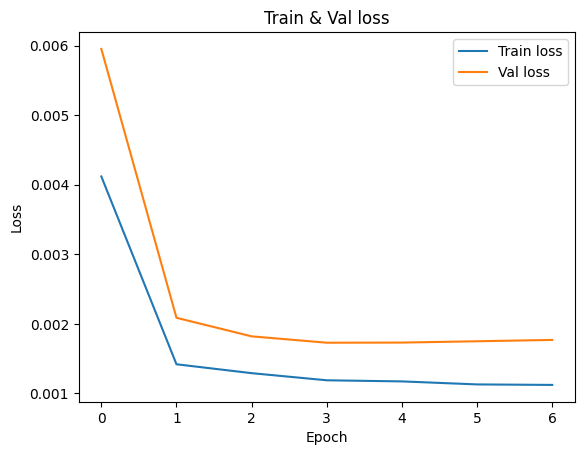

In [14]:
def plot_history(history):                          # function to ploss loss history on training data set
    plt.plot(history.history['loss'], label='Train loss')
    plt.plot(history.history['val_loss'], label='Val loss')
    plt.title('Train & Val loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

plot_history(history)

In [15]:
y_pred = model.predict(X_test)

1961/1961 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step


In [16]:
# Create dummy prediction to compare to
target_cols = ['MM_RATE']
feature_cols = [c for c in test_data.columns if c != "ALERT"]
target_idx = [feature_cols.index(c) for c in target_cols]

# Repeat last observed target values across the whole horizon
last_obs = X_test[:, -1, target_idx]
y_dummy = np.repeat(last_obs[:, None, :], y_test.shape[1], axis=1)
y_dummy.shape

(62744, 120, 1)

In [17]:
def evaluate_forecast(y_true, y_pred, name):
    yt = y_true.reshape(-1, y_true.shape[-1])
    yp = y_pred.reshape(-1, y_pred.shape[-1])

    print(name)
    print("pinball:", pinball_loss_keras(y_true, y_pred, quantile=0.9))
    print("mae:", mean_absolute_error(yt, yp))
    print("mse:", mean_squared_error(yt, yp))
    print("mape:", mean_absolute_percentage_error(yt, yp))
    print("mae per target:", mean_absolute_error(yt, yp, multioutput="raw_values"))
    print("mse per target:", mean_squared_error(yt, yp, multioutput="raw_values"))
    print()

In [18]:
evaluate_forecast(y_test, y_dummy, "Dummy")
evaluate_forecast(y_test, y_pred, "LSTM")

Dummy
pinball: tf.Tensor(0.00089954596, shape=(), dtype=float32)
mae: 0.003367081517353654
mse: 0.0005115523235872388
mape: 0.16239643096923828
mae per target: [0.00336708]
mse per target: [0.00051155]

LSTM
pinball: tf.Tensor(0.0011463176, shape=(), dtype=float32)
mae: 0.0072293528355658054
mse: 0.0002187653153669089
mape: 0.3089233338832855
mae per target: [0.00722935]
mse per target: [0.00021877]



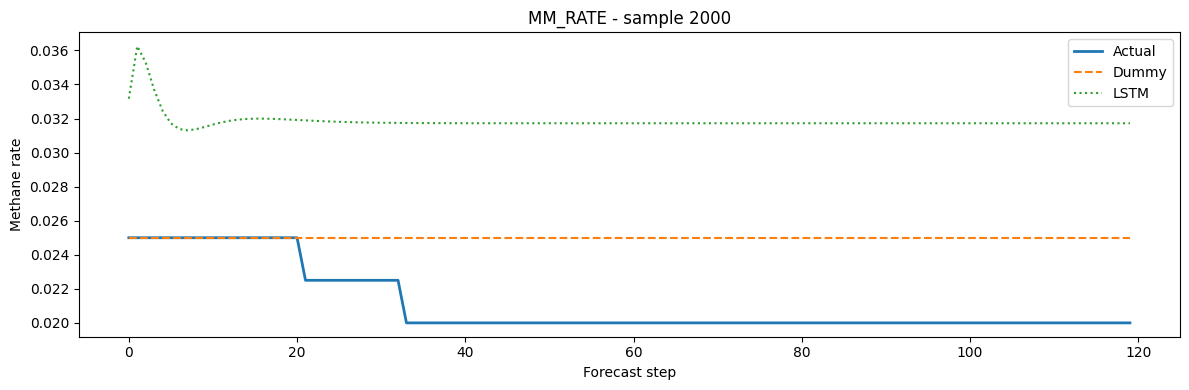

In [19]:
# plot the prediction versus actuals for MM_RATE reading on 1 sequence
sample_idx = 2000
target_idx = 0

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y_test[sample_idx, :, target_idx], label="Actual", linewidth=2)
ax.plot(y_dummy[sample_idx, :, target_idx], label="Dummy", linestyle="--")
ax.plot(y_pred[sample_idx, :, target_idx], label="LSTM", linestyle=":")
ax.set_title(f"MM_RATE - sample {sample_idx}")
ax.set_xlabel("Forecast step")
ax.set_ylabel("Methane rate")
ax.legend()
plt.tight_layout()
plt.show()

In [28]:
# save X_train, y_train, X_test, y_train plus the scalers and training parameters

import os
import json
import joblib
from datetime import datetime

os.makedirs("data_cache", exist_ok=True)

artifact_name = "lstm_data_v3"

# 1. Save arrays
np.savez_compressed(
    f"data_cache/{artifact_name}.npz",
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test)

# 2. Save scalers
joblib.dump(scalers, f"data_cache/{artifact_name}_scalers.joblib")

# 3. Save metadata
metadata = {
    "artifact_name": artifact_name,
    "created_at": datetime.now().isoformat(),
    "source_notebook": "preprocess_debug.ipynb",
    "X_train_shape": X_train.shape,
    "y_train_shape": y_train.shape,
    "X_test_shape": X_test.shape,
    "y_test_shape": y_test.shape,
    "feature_columns": list(train_data.columns.drop("ALERT")),
    "target_columns": ["MM256", "MM263", "MM264"],
    "excluded_columns": ["datetime", "slice_id", "trigger_time", "t_rel_s", "ALERT"],
    "window_length_in_sec": 100,
    "forecast_horizon_in_sec": 60,
    "input_length_in_sec": 40,
    "train_slice_start_index": 2_800_000,
    "train_slice_stop_index": 5_200_000,
    "test_slice_start_index": 400_000,
    "test_slice_stop_index": 1_300_000,
    "scaling": "MinMaxScaler per numeric feature fitted on train split only"}

with open(f"data_cache/{artifact_name}_meta.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved:")
print(f"  data_cache/{artifact_name}.npz")
print(f"  data_cache/{artifact_name}_scalers.joblib")
print(f"  data_cache/{artifact_name}_meta.json")


Saved:
  data_cache/lstm_data_v3.npz
  data_cache/lstm_data_v3_scalers.joblib
  data_cache/lstm_data_v3_meta.json


In [ ]:
# print directory where the files are saved and file names
print(os.path.abspath("data_cache"))
print(os.listdir("data_cache"))

/home/gritty_ch/code/ArthurVigier/grisounet/data_cache
['lstm_data_v1_scalers.joblib', 'lstm_data_v1_meta.json', 'lstm_data_v1.npz']
